# 04 — Fusión de Canales EMG

Este notebook combina la información de 8 canales en una sola variable por feature,
evaluando múltiples estrategias de fusión y el efecto de la normalización por sujeto.

**Pipeline:**
1. Carga de datos transformados (Box-Cox)
2. Normalización Z-score por sujeto
3. η² baseline (canales individuales)
4. Funciones de fusión (6 métodos)
5. η² con fusión — sin normalización por sujeto
6. η² con fusión — con normalización por sujeto
7. Tabla resumen y selección del mejor método por feature
8. Construcción del dataset fused
9. Verificación final

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

FEATURES = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']
N_CHANNELS = 8

## 1. Carga de datos

In [68]:
ruta='../data/master/intact_boxcox_mean.csv'

In [69]:
df = pd.read_csv(ruta)

meta_cols = ['origin_db', 'subject', 'stimulus']
signal_cols = [f'Channel {ch}_{feat}' for ch in range(1, N_CHANNELS + 1) for feat in FEATURES]

print(f'Shape: {df.shape}')
print(f'Sujetos: {df["subject"].nunique()}')
print(f'Estímulos: {sorted(df["stimulus"].unique())}')
print(f'Columnas de señal: {len(signal_cols)}')
df.head()

Shape: (696, 67)
Sujetos: 40
Estímulos: [np.int64(0), np.int64(22), np.int64(25), np.int64(27), np.int64(30), np.int64(31), np.int64(37), np.int64(40)]
Columnas de señal: 64


,origin_db,subject,stimulus,Channel 1_VAR_STD,Channel 2_VAR_STD,Channel 3_VAR_STD,Channel 4_VAR_STD,Channel 5_VAR_STD,Channel 6_VAR_STD,Channel 7_VAR_STD,...,Channel 7_MNF,Channel 8_MNF,Channel 1_SSC,Channel 2_SSC,Channel 3_SSC,Channel 4_SSC,Channel 5_SSC,Channel 6_SSC,Channel 7_SSC,Channel 8_SSC
0,NinaProDB1,1,0,3.245820,2.498359,3.663975,2.093551,-0.343541,-0.130899,4.016491,...,124.108122,134.740009,107.145650,32.581307,52.075523,31.666510,42.486490,25.214515,62.830390,102.329083
1,NinaProDB1,1,22,-0.499764,0.583024,0.578080,-1.553525,-4.470131,-3.047323,0.572354,...,14.583208,12.888661,12.297331,10.553926,11.849171,7.430069,7.727680,7.861365,10.574872,12.663580
2,NinaProDB1,1,25,-0.313625,-0.497969,0.010796,-1.152653,-4.357116,-3.780682,1.646615,...,13.835902,12.363764,11.497034,9.265589,9.922973,8.825654,7.029264,6.641773,10.605005,12.691204
3,NinaProDB1,1,27,0.681678,-0.065446,0.363523,-2.442917,-4.438125,-2.116573,0.887429,...,14.422711,12.181623,14.339522,12.075083,11.185033,7.723774,7.755211,8.257302,11.312438,13.797904
4,NinaProDB1,1,30,1.668028,1.752934,1.344338,-0.669122,-3.466963,-3.454427,1.488262,...,13.780039,12.350112,13.167399,10.269074,10.034869,6.892439,8.064009,8.077701,11.126373,12.809900


## 2. Normalización Z-score por sujeto

In [70]:
def normalize_by_subject(df, signal_cols):
    """
    Aplica Z-score (StandardScaler) por cada sujeto sobre las columnas de señal.
    Elimina diferencias de amplitud inter-sujeto.
    """
    df_norm = df.copy()
    for subj, db in df_norm.groupby(['subject', 'origin_db']).groups.keys():
        mask = (df_norm['subject'] == subj) & (df_norm['origin_db'] == db)
        sub_data = df_norm.loc[mask, signal_cols].values.astype(float)
        
        # Si el sujeto tiene 1 sola fila, no se puede standardizar
        if sub_data.shape[0] < 2:
            df_norm.loc[mask, signal_cols] = 0.0
            continue
        
        # Si alguna feature tiene std=0, reemplazar por 0
        stds = np.nanstd(sub_data, axis=0, ddof=1)
        stds[stds == 0] = 1.0  # evitar división por cero
        means = np.nanmean(sub_data, axis=0)
        df_norm.loc[mask, signal_cols] = (sub_data - means) / stds
    
    return df_norm


df_norm = normalize_by_subject(df, signal_cols)
print('Normalización por sujeto completada.')
print(f'Shape original: {df.shape}, Shape normalizado: {df_norm.shape}')

Normalización por sujeto completada.
Shape original: (696, 67), Shape normalizado: (696, 67)


## 3. η² baseline — canales individuales (sin fusión, sin normalización)

Calculamos η² para cada canal individual con los datos **sin normalizar**.
Este es el baseline: cuánta separabilidad hay por canal antes de cualquier fusión.

In [71]:
def separability_eta2(groups):
    """
    Calcula eta² (η²) = SS_between / SS_total.
    groups: lista de arrays, uno por clase/estímulo.
    """
    groups = [g[np.isfinite(g)] for g in groups]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return np.nan
    all_data = np.concatenate(groups)
    if all_data.size == 0:
        return np.nan
    gm = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - gm) ** 2 for g in groups)
    ss_total = ((all_data - gm) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else np.nan


def compute_eta2_per_channel(df, features, n_channels=8, stimulus_col='stimulus'):
    """
    Calcula η² para cada canal individual de cada feature.
    """
    rows = []
    for feat in features:
        for ch in range(1, n_channels + 1):
            col = f'Channel {ch}_{feat}'
            if col not in df.columns:
                continue
            groups = [x[col].dropna().values for _, x in df.groupby(stimulus_col)]
            eta2 = separability_eta2(groups)
            rows.append({'feature': feat, 'channel': ch, 'eta2': eta2})
    return pd.DataFrame(rows)


# Baseline: sin normalización por sujeto
eta2_baseline = compute_eta2_per_channel(df, FEATURES)
print('η² baseline (canales individuales, sin normalización por sujeto):')
eta2_baseline.pivot(index='feature', columns='channel', values='eta2').round(4)

η² baseline (canales individuales, sin normalización por sujeto):


channel,1,2,3,4,5,6,7,8
feature,,,,,,,,
Energy,0.0133,0.0098,0.0085,0.0083,0.0116,0.0105,0.0085,0.0084
MNF,0.7290,0.6707,0.6846,0.6196,0.6386,0.6663,0.6774,0.7029
Max,0.0461,0.0319,0.0305,0.0329,0.0398,0.0378,0.0391,0.0390
Peak_to_Peak,0.0634,0.0437,0.0384,0.0387,0.0490,0.0443,0.0478,0.0478
Range,0.0393,0.0266,0.0225,0.0240,0.0287,0.0312,0.0316,0.0307
SSC,0.6861,0.5731,0.5986,0.5411,0.5823,0.6183,0.6730,0.6933
VAR,0.0119,0.0102,0.0090,0.0092,0.0117,0.0130,0.0081,0.0076
VAR_STD,0.0137,0.0107,0.0091,0.0082,0.0109,0.0103,0.0084,0.0084


In [72]:
# η² baseline: canales individuales, CON normalización por sujeto
eta2_baseline_norm = compute_eta2_per_channel(df_norm, FEATURES)
print('η² baseline (canales individuales, CON normalización por sujeto):')
eta2_baseline_norm.pivot(index='feature', columns='channel', values='eta2').round(4)

η² baseline (canales individuales, CON normalización por sujeto):


channel,1,2,3,4,5,6,7,8
feature,,,,,,,,
Energy,0.7495,0.7060,0.6523,0.6096,0.6712,0.7148,0.6725,0.7059
MNF,0.9999,0.9992,0.9996,0.9988,0.9986,0.9984,0.9987,0.9999
Max,0.9328,0.9087,0.8981,0.8851,0.9048,0.9220,0.9264,0.9372
Peak_to_Peak,0.9293,0.8982,0.8781,0.8436,0.8857,0.9188,0.9364,0.9370
Range,0.8718,0.8239,0.7751,0.7360,0.7884,0.8103,0.8233,0.8679
SSC,0.9996,0.9905,0.9981,0.9881,0.9970,0.9936,0.9970,0.9990
VAR,0.6207,0.6244,0.5466,0.4721,0.5481,0.5481,0.4772,0.5617
VAR_STD,0.7824,0.7381,0.6795,0.6023,0.6944,0.7264,0.6890,0.7431


## 4. Funciones de fusión

In [73]:
def fuse_channels(df, feature, method, n_channels=8):
    """
    Fusiona los 8 canales de una feature en una sola variable.
    
    Parámetros:
        df     : DataFrame con las columnas Channel {1-8}_{feature}
        feature: nombre de la feature (ej. 'VAR_STD')
        method : str — 'mean', 'median', 'pca', 'wmean', 'max', 'std'
    """
    cols = [f'Channel {ch}_{feature}' for ch in range(1, n_channels + 1)]
    cols = [c for c in cols if c in df.columns]
    X = df[cols].values.astype(float)
    
    if method == 'mean':
        return np.nanmean(X, axis=1)
    elif method == 'median':
        return np.nanmedian(X, axis=1)
    elif method == 'pca':
        # PCA: primera componente principal
        X_clean = np.nan_to_num(X, nan=0.0)
        if X_clean.shape[0] < 2:
            return np.nanmean(X, axis=1)
        pca = PCA(n_components=1)
        return pca.fit_transform(X_clean).ravel()
    elif method == 'wmean':
        # Media ponderada: peso = 1 / varianza del canal
        vars_ = np.nanvar(X, axis=0)
        vars_[vars_ == 0] = 1e-10  # evitar división por cero
        weights = 1.0 / vars_
        weights = weights / weights.sum()  # normalizar pesos
        return np.nansum(X * weights, axis=1)
    elif method == 'max':
        return np.nanmax(X, axis=1)
    elif method == 'std':
        return np.nanstd(X, axis=1)
    else:
        raise ValueError(f'Método desconocido: {method}')


def fuse_all_features(df, features, method, n_channels=8):
    """
    Fusiona todas las features de un DataFrame usando un método dado.
    Devuelve un DataFrame con las columnas fused.
    """
    result = df[['origin_db', 'subject', 'stimulus']].copy()
    for feat in features:
        result[f'Fused_{feat}'] = fuse_channels(df, feat, method, n_channels)
    return result


print('Funciones de fusión definidas: mean, median, pca, wmean, max, std')

Funciones de fusión definidas: mean, median, pca, wmean, max, std


## 6. η² con fusión — CON normalización por sujeto

In [74]:
def compute_eta2_fusion(df, features, methods, n_channels=8, stimulus_col='stimulus'):
    """
    Calcula η² para cada feature × cada método de fusión.
    """
    rows = []
    for feat in features:
        for method in methods:
            fused = fuse_channels(df, feat, method, n_channels)
            groups = [fused[df[stimulus_col] == s] for s in sorted(df[stimulus_col].unique())]
            groups = [g[np.isfinite(g)] for g in groups]
            eta2 = separability_eta2(groups)
            rows.append({'feature': feat, 'method': method, 'eta2': eta2})
    return pd.DataFrame(rows)

# Con normalización por sujeto
METHODS = ['mean', 'median', 'pca', 'wmean', 'max', 'std']
eta2_fusion_norm = compute_eta2_fusion(df_norm, FEATURES, METHODS)
print('η² con fusión — CON normalización por sujeto:')
eta2_fusion_norm.pivot(index='feature', columns='method', values='eta2').round(4)

η² con fusión — CON normalización por sujeto:


method,max,mean,median,pca,std,wmean
feature,,,,,,
Energy,0.7239,0.8433,0.8312,0.8431,0.1188,0.8433
MNF,0.9989,0.9997,0.9997,0.9997,0.7226,0.9997
Max,0.9147,0.9645,0.9635,0.9645,0.2801,0.9645
Peak_to_Peak,0.9172,0.9642,0.9658,0.9643,0.2956,0.9642
Range,0.8431,0.9161,0.9123,0.9163,0.2480,0.9161
SSC,0.9913,0.9988,0.9994,0.9988,0.3229,0.9988
VAR,0.6134,0.7368,0.7099,0.7356,0.1888,0.7368
VAR_STD,0.7491,0.8658,0.8576,0.8664,0.1868,0.8658


## 7. Tabla resumen y selección del mejor método

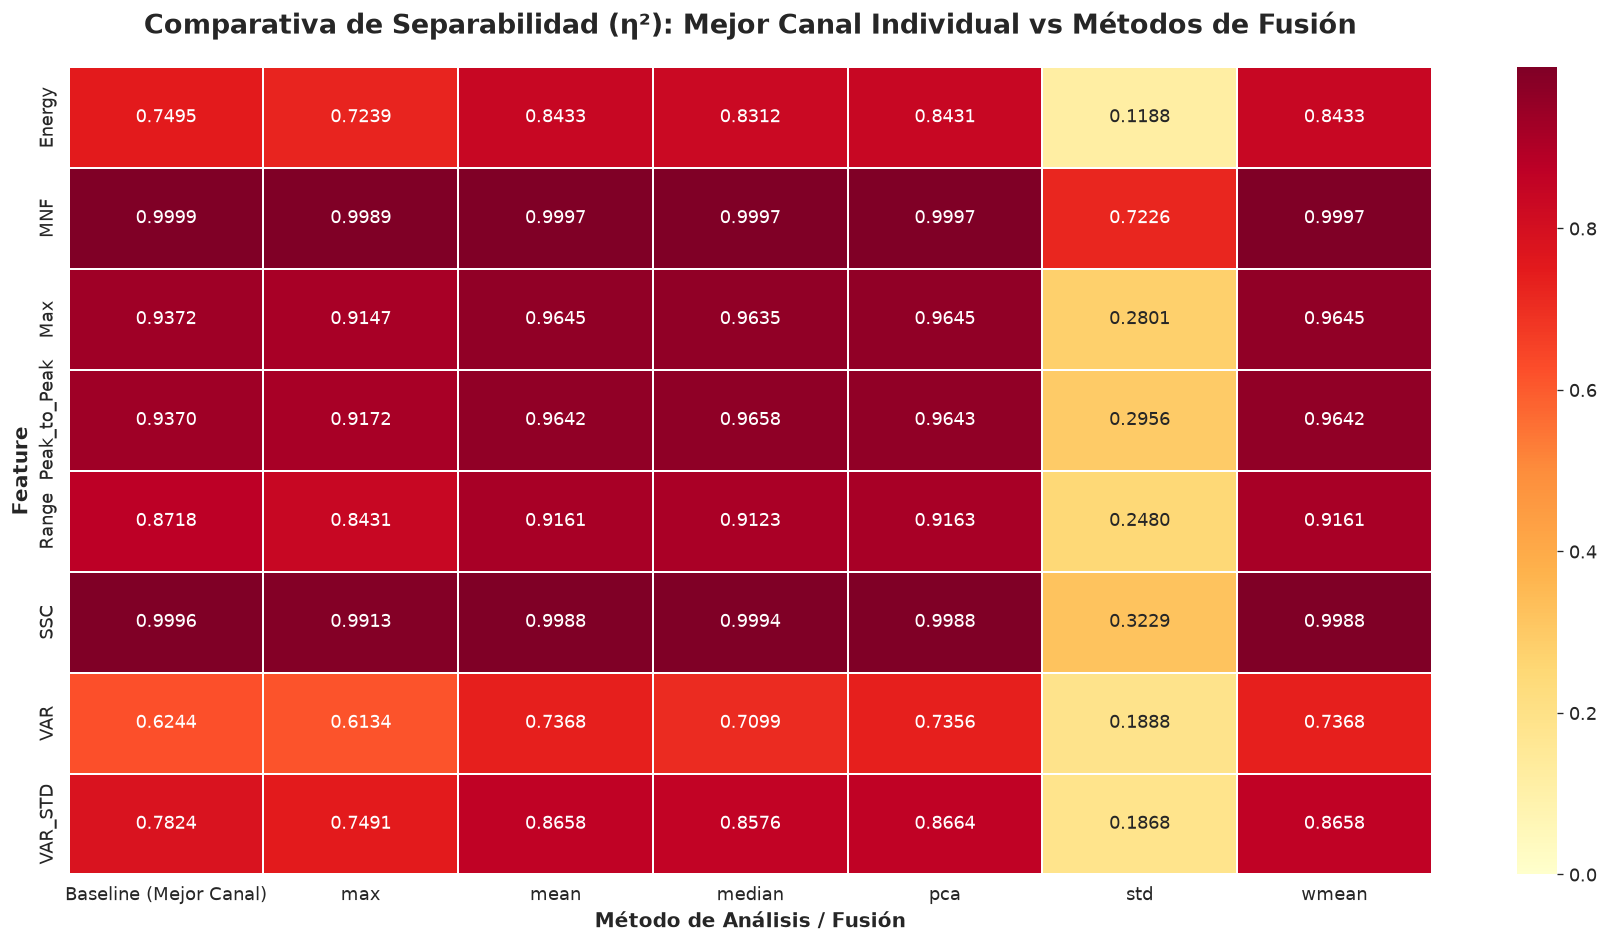

In [75]:
# 1. EXTRACCIÓN SEGURA DEL BASELINE
# Forzamos la creación de un DataFrame con el valor MÁXIMO real por feature
baseline_list = []
for feat in FEATURES:
    # Filtramos todas las filas de esa feature en el baseline
    feat_data = eta2_baseline_norm[eta2_baseline_norm['feature'] == feat]
    # Buscamos el valor máximo de eta2 entre los 8 canales
    max_val = feat_data['eta2'].max() 
    baseline_list.append({'feature': feat, 'method': 'Baseline (Mejor Canal)', 'eta2': max_val})

df_baseline_max = pd.DataFrame(baseline_list)

# 2. Preparar los datos de Fusión (estos ya vienen correctos por feature)
fusion_data = eta2_fusion_norm[['feature', 'method', 'eta2']]

# 3. Unir Baseline + Fusión
df_compare = pd.concat([df_baseline_max, fusion_data], ignore_index=True)

# 4. Pivotar para el Heatmap
pivot_compare = df_compare.pivot(index='feature', columns='method', values='eta2')

# Asegurar que el Baseline esté a la izquierda
cols = ['Baseline (Mejor Canal)'] + [m for m in pivot_compare.columns if m != 'Baseline (Mejor Canal)']
pivot_compare = pivot_compare[cols]

# 5. Visualización
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_compare, 
            annot=True, 
            fmt='.4f', 
            cmap='YlOrRd', 
            linewidths=1, 
            linecolor='white', 
            vmin=0, 
            vmax=pivot_compare.max().max())

plt.title('Comparativa de Separabilidad (η²): Mejor Canal Individual vs Métodos de Fusión', 
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Método de Análisis / Fusión', fontweight='bold', fontsize=12)
plt.ylabel('Feature', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [76]:
# Tabla resumen: mejor método por feature (con normalización por sujeto)
best_methods = eta2_fusion_norm.loc[
    eta2_fusion_norm.groupby('feature')['eta2'].idxmax()
][['feature', 'method', 'eta2']].reset_index(drop=True)
best_methods.columns = ['Feature', 'Mejor_método', 'η²']

# Agregar η² del baseline (mejor canal individual)
best_baseline = eta2_baseline_norm.groupby('feature')['eta2'].max().reset_index()
best_baseline.columns = ['Feature', 'η²_baseline']

summary = best_methods.merge(best_baseline, on='Feature')
summary['Mejora_%'] = ((summary['η²'] - summary['η²_baseline']) / summary['η²_baseline'] * 100)
summary = summary.round(4)

print('Tabla resumen — Mejor método por feature (con normalización por sujeto):')
print(summary.to_string(index=False))

Tabla resumen — Mejor método por feature (con normalización por sujeto):
     Feature Mejor_método     η²  η²_baseline  Mejora_%
      Energy         mean 0.8433       0.7495   12.5028
         MNF       median 0.9997       0.9999   -0.0187
         Max          pca 0.9645       0.9372    2.9082
Peak_to_Peak       median 0.9658       0.9370    3.0798
       Range          pca 0.9163       0.8718    5.1033
         SSC       median 0.9994       0.9996   -0.0170
         VAR         mean 0.7368       0.6244   17.9887
     VAR_STD          pca 0.8664       0.7824   10.7344


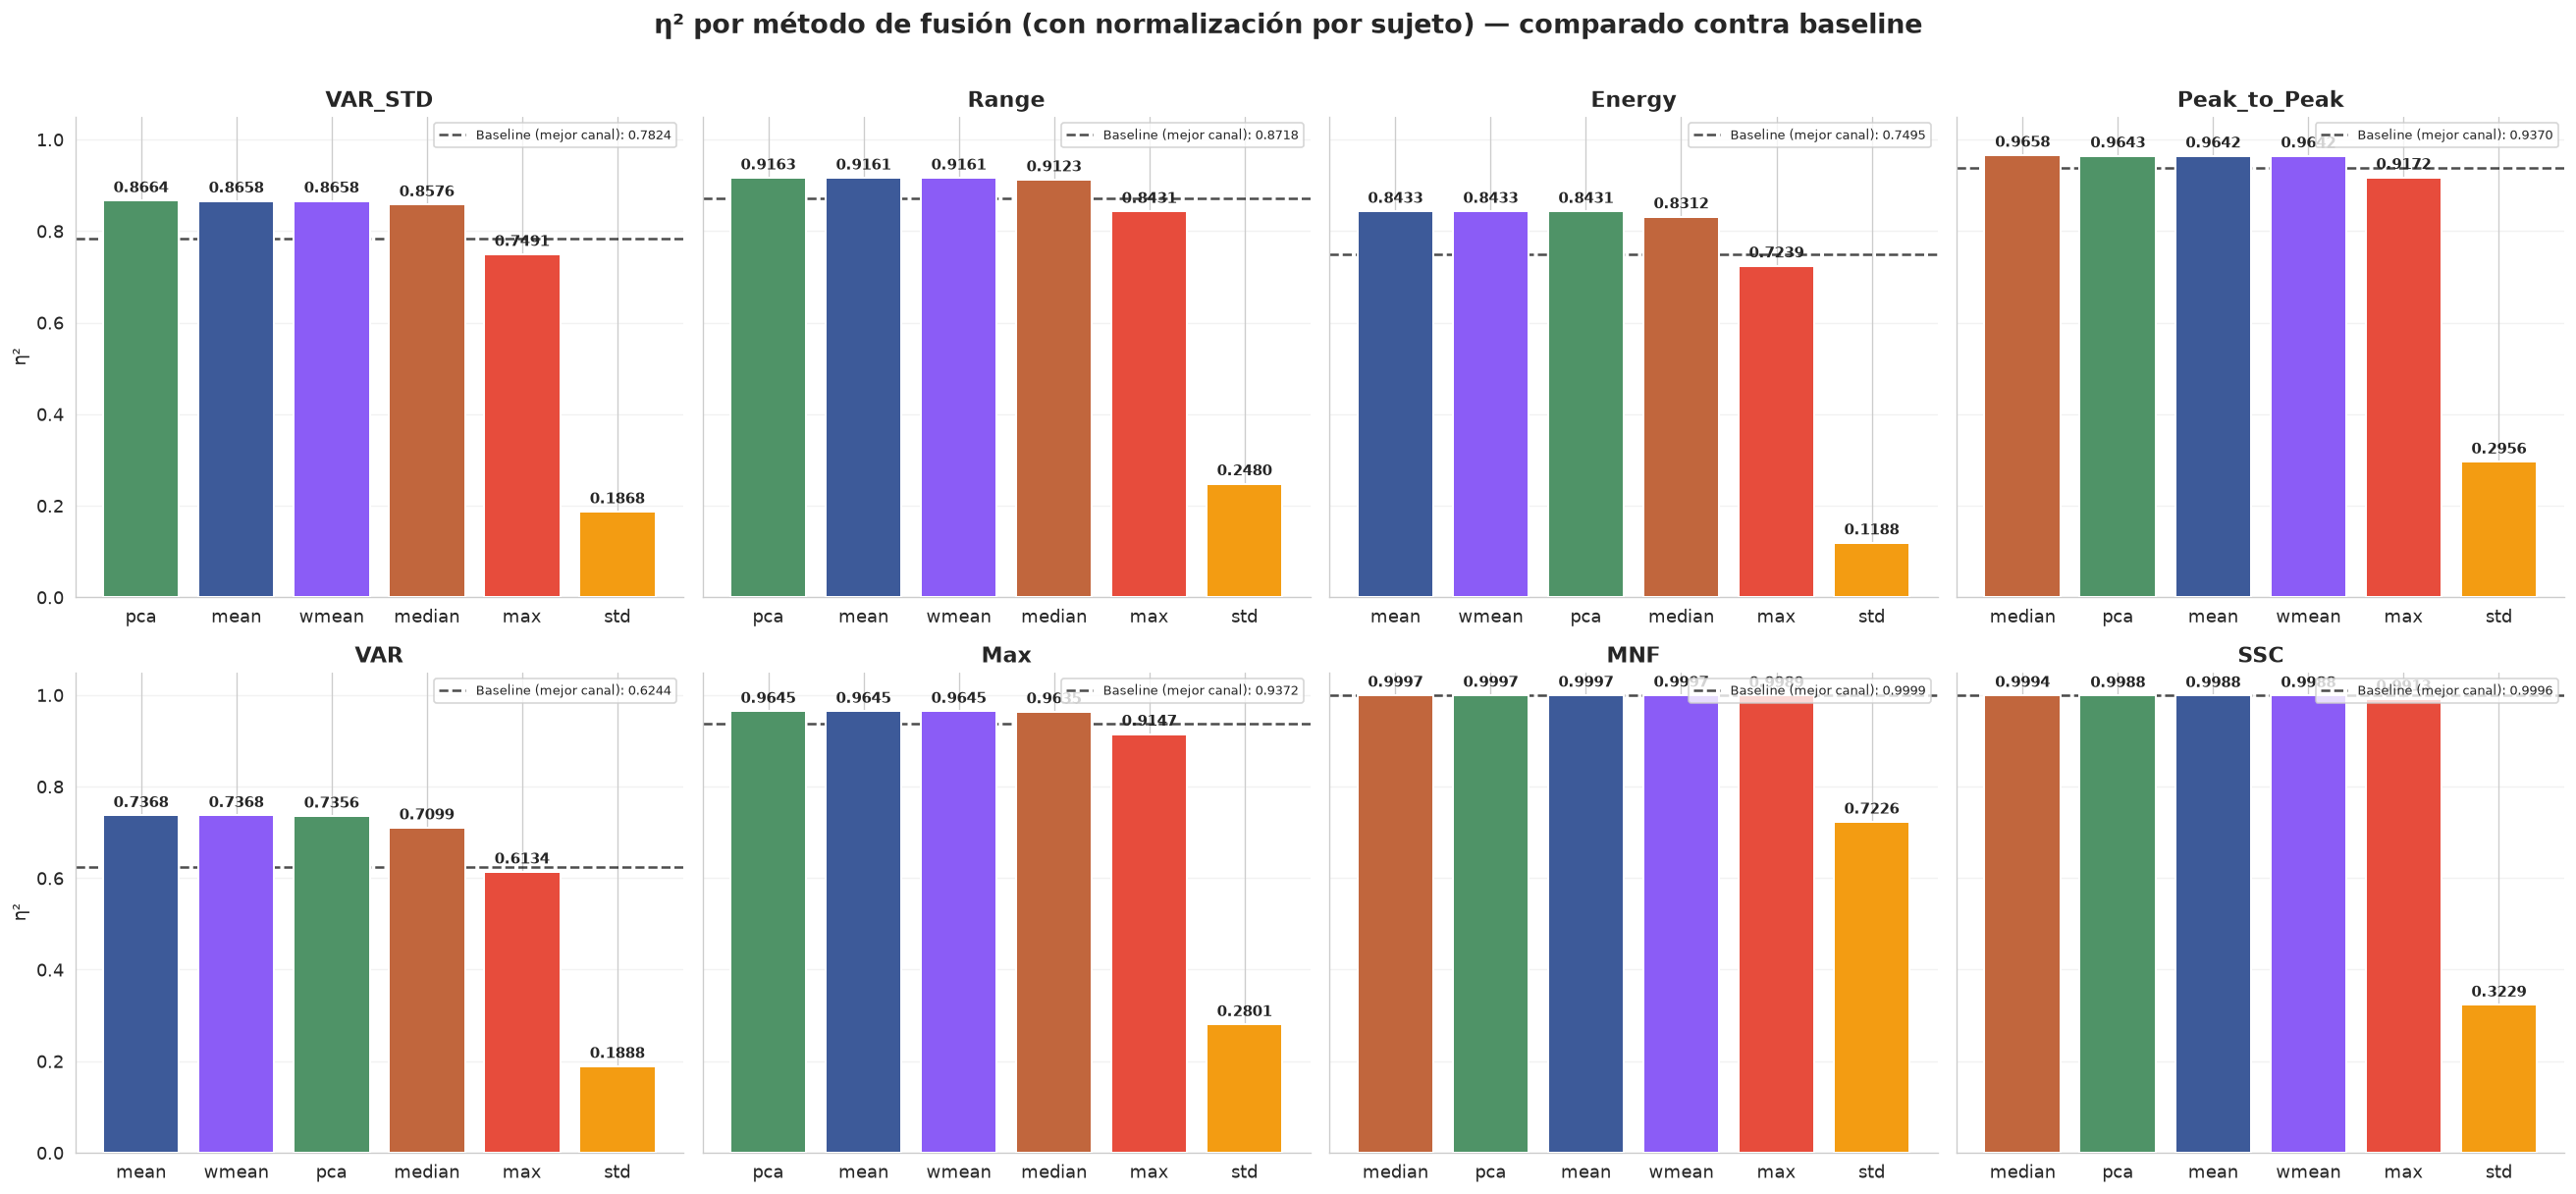

In [77]:
# Barras agrupadas: comparación de los 6 métodos por feature
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()

colors = {'mean': '#3d5a99', 'median': '#c1663d', 'pca': '#4f9367',
          'wmean': '#8b5cf6', 'max': '#e74c3c', 'std': '#f39c12'}

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    sub = eta2_fusion_norm[eta2_fusion_norm['feature'] == feat].copy()
    sub = sub.sort_values('eta2', ascending=False)
    
    bars = ax.bar(sub['method'], sub['eta2'], color=[colors[m] for m in sub['method']],
                  edgecolor='white', linewidth=1.2, zorder=3)
    ax.bar_label(bars, fmt='%.4f', fontsize=9, fontweight='bold', padding=3)
    
    # Línea del baseline (mejor canal individual)
    bl = eta2_baseline_norm[eta2_baseline_norm['feature'] == feat]['eta2'].max()
    ax.axhline(bl, color='black', ls='--', lw=1.5, alpha=0.7, label=f'Baseline (mejor canal): {bl:.4f}')
    
    ax.set_title(feat, fontweight='bold', fontsize=13)
    ax.set_ylabel('η²' if i % 4 == 0 else '')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.legend(fontsize=8, loc='upper right')
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

fig.suptitle('η² por método de fusión (con normalización por sujeto) — comparado contra baseline',
             fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

## 8. Construcción del dataset fused

In [78]:
# Construir el dataset fused usando el mejor método por feature sobre datos normalizados
best_method_dict = dict(zip(summary['Feature'], summary['Mejor_método']))
print('Mejores métodos por feature:')
for feat, method in best_method_dict.items():
    print(f'  {feat}: {method}')

# Aplicar fusión
df_fused = df_norm[['origin_db', 'subject', 'stimulus']].copy()
for feat in FEATURES:
    method = best_method_dict[feat]
    df_fused[feat] = fuse_channels(df_norm, feat, method)

print(f'\nShape del dataset fused: {df_fused.shape}')
df_fused.head()

Mejores métodos por feature:
  Energy: mean
  MNF: median
  Max: pca
  Peak_to_Peak: median
  Range: pca
  SSC: median
  VAR: mean
  VAR_STD: pca

Shape del dataset fused: (696, 11)


,origin_db,subject,stimulus,VAR_STD,Range,Energy,Peak_to_Peak,VAR,Max,MNF,SSC
0,NinaProDB1,1,0,5.593093,6.248140,1.956540,2.335755,1.815807,6.575719,2.473600,2.467803
1,NinaProDB1,1,22,-0.803552,-0.657140,-0.398947,-0.284844,-0.184912,-1.053957,-0.348391,-0.379306
2,NinaProDB1,1,25,-0.882335,-0.365818,-0.260100,-0.497061,-0.030204,-1.008664,-0.360626,-0.411105
3,NinaProDB1,1,27,-0.532825,-0.731349,-0.295665,-0.314893,-0.195243,-0.994126,-0.339719,-0.325179
4,NinaProDB1,1,30,0.915542,0.516173,0.228479,-0.000204,0.505130,-0.195221,-0.363147,-0.368967


In [79]:
# Guardar
df_fused.to_csv('../data/master/intact_boxcox_fused.csv', index=False)
print('Dataset fused guardado en: data/master/intact_boxcox_fused.csv')

Dataset fused guardado en: data/master/intact_boxcox_fused.csv


In [80]:
# 1. Identificar el mejor canal para cada feature
# Partimos de eta2_baseline_norm que tiene ['feature', 'channel', 'eta2']
idx_best_channels = eta2_baseline_norm.groupby('feature')['eta2'].idxmax()
best_channels_info = eta2_baseline_norm.loc[idx_best_channels, ['feature', 'channel']]

# 2. Crear el DataFrame de comparación
# Empezamos con la metadata básica
df_best_channels = df_norm[['origin_db', 'subject', 'stimulus']].copy()

# 3. Extraer la columna del mejor canal para cada feature
for _, row in best_channels_info.iterrows():
    feat = row['feature']
    ch = int(row['channel'])
    
    col_name = f'Channel {ch}_{feat}'
    
    # Guardamos la columna con el nombre de la feature para facilitar comparaciones
    df_best_channels[feat] = df_norm[col_name]

# 4. Verificación final
print("Canales seleccionados como los mejores por feature:")
print(best_channels_info.set_index('feature'))

print(f"\nShape del DataFrame resultante: {df_best_channels.shape}")
df_best_channels.head()

Canales seleccionados como los mejores por feature:
              channel
feature              
Energy              1
MNF                 1
Max                 8
Peak_to_Peak        8
Range               1
SSC                 1
VAR                 2
VAR_STD             1

Shape del DataFrame resultante: (696, 11)


,origin_db,subject,stimulus,Energy,MNF,Max,Peak_to_Peak,Range,SSC,VAR,VAR_STD
0,NinaProDB1,1,0,1.840195,2.474536,2.427982,2.414737,2.050359,2.472054,1.398929,1.640922
1,NinaProDB1,1,22,-0.486083,-0.347819,-0.526662,-0.561471,-0.356713,-0.380901,0.179910,-0.413864
2,NinaProDB1,1,25,-0.584943,-0.339152,-0.358315,-0.476777,-0.152426,-0.404973,-0.636064,-0.311751
3,NinaProDB1,1,27,0.258750,-0.355970,-0.356966,-0.325194,0.105101,-0.319473,-0.629495,0.234262
4,NinaProDB1,1,30,0.923902,-0.347659,-0.417100,-0.299214,0.533114,-0.354730,1.119179,0.775363


In [81]:
df_best_channels.to_csv('../data/master/intact_boxcox_best_channels.csv', index=False)

In [82]:
df_norm.to_csv('../data/master/intact_boxcox_normalized.csv', index=False)

## 9. Verificación final

In [83]:
# Verificar η² del dataset fused

eta2_fused = []
for feat in FEATURES:
    col = feat
    groups = [x[col].dropna().values for _, x in df_fused.groupby('stimulus')]
    eta2 = separability_eta2(groups)
    eta2_fused.append({'feature': feat, 'η²_fused': eta2})

eta2_fused_df = pd.DataFrame(eta2_fused)

# Comparar con el mejor η² de fusión (de la tabla resumen)
comparison = summary[['Feature', 'η²', 'Mejor_método']].merge(eta2_fused_df, left_on='Feature', right_on='feature')
comparison = comparison[['Feature', 'Mejor_método', 'η²', 'η²_fused']]
comparison.columns = ['Feature', 'Método', 'η² teórico', 'η² verificado']
print('Verificación del dataset fused:')
print(comparison.round(4).to_string(index=False))

Verificación del dataset fused:
     Feature Método  η² teórico  η² verificado
      Energy   mean      0.8433         0.8433
         MNF median      0.9997         0.9997
         Max    pca      0.9645         0.9645
Peak_to_Peak median      0.9658         0.9658
       Range    pca      0.9163         0.9163
         SSC median      0.9994         0.9994
         VAR   mean      0.7368         0.7368
     VAR_STD    pca      0.8664         0.8664


/tmp/ipykernel_24829/2146837867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
/tmp/ipykernel_24829/2146837867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
/tmp/ipykernel_24829/2146837867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
/tmp/ipykernel_24829/2146837867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

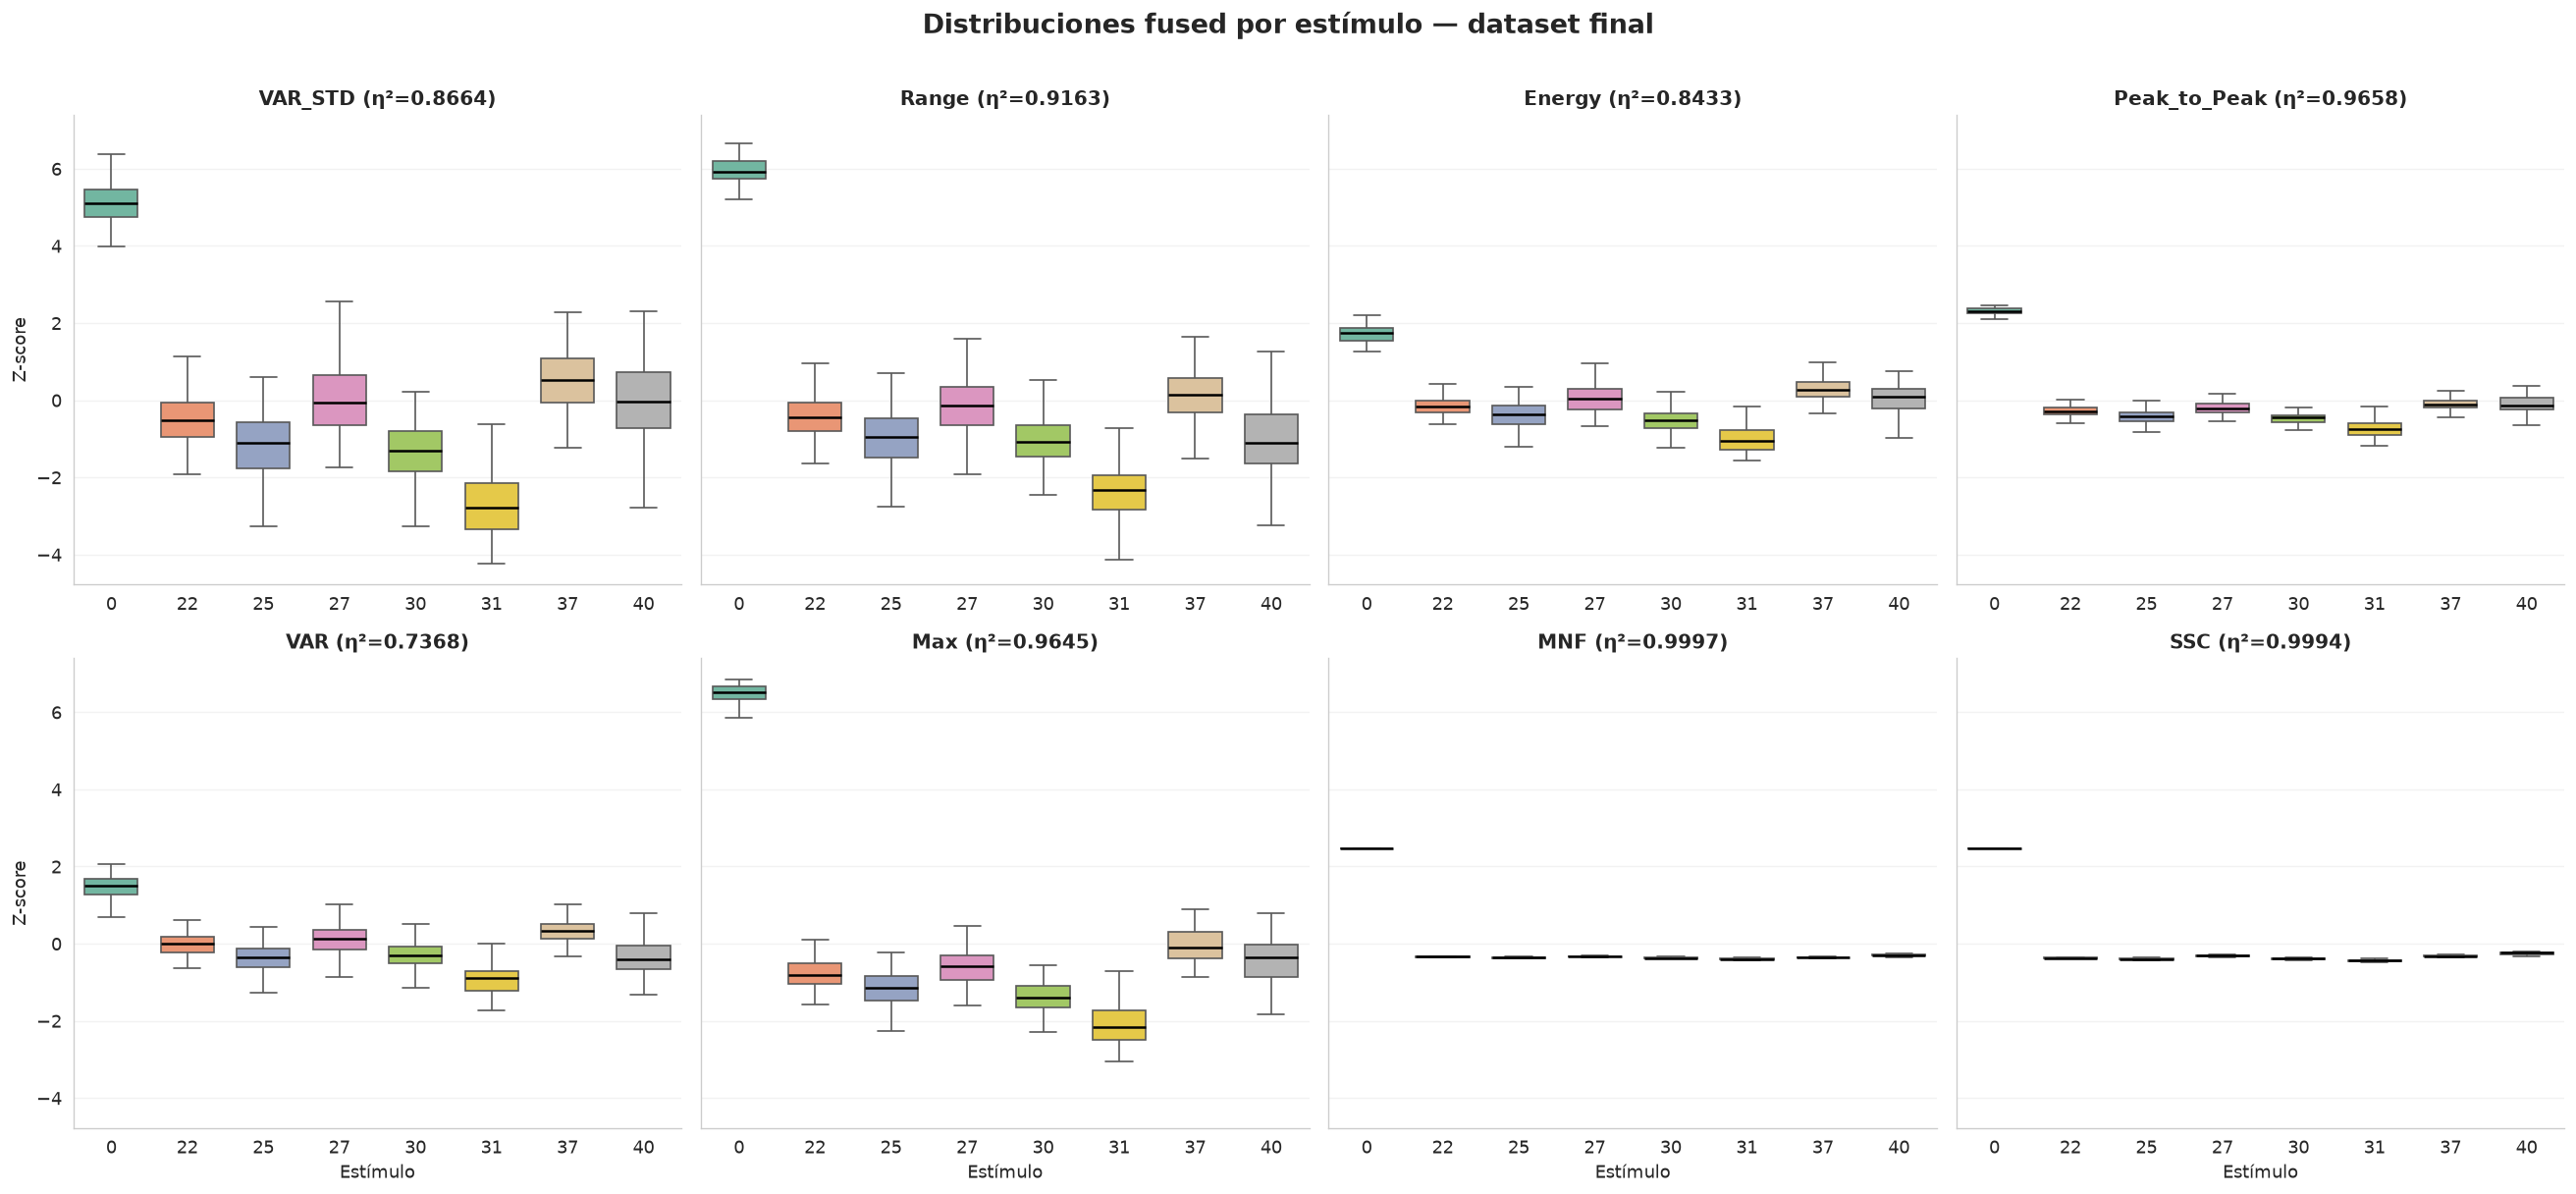

In [84]:
# Distribuciones fused por estimulo (boxplot)
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    col = feat
    sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
                palette='Set2', showfliers=False, width=0.7,
                medianprops=dict(color='black', linewidth=1.5))
    ax.set_title(f'{feat} (η²={eta2_fused_df.loc[eta2_fused_df["feature"]==feat, "η²_fused"].values[0]:.4f})',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Estímulo' if i >= 4 else '')
    ax.set_ylabel('Z-score' if i % 4 == 0 else '')
    ax.grid(axis='y', alpha=0.25)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

fig.suptitle('Distribuciones fused por estímulo — dataset final',
             fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

In [85]:
# Silhouette score global del dataset fused
from sklearn.metrics import silhouette_score

X_fused = df_fused[FEATURES].values
labels = df_fused['stimulus'].values

# Filtrar NaN
mask = ~np.isnan(X_fused).any(axis=1)
sil = silhouette_score(X_fused[mask], labels[mask])
print(f'Silhouette score del dataset fused: {sil:.4f}')

# Comparar con el dataset original (mejores canales)
best_channel_cols = []
for feat in FEATURES:
    best_ch = eta2_baseline_norm[eta2_baseline_norm['feature'] == feat].sort_values('eta2', ascending=False).iloc[0]['channel']
    best_channel_cols.append(f'Channel {int(best_ch)}_{feat}')

X_best = df_norm[best_channel_cols].values
mask2 = ~np.isnan(X_best).any(axis=1)
sil_baseline = silhouette_score(X_best[mask2], labels[mask2])
print(f'Silhouette score baseline (mejores canales individuales): {sil_baseline:.4f}')

Silhouette score del dataset fused: 0.0590
Silhouette score baseline (mejores canales individuales): 0.0752


In [86]:
def plot_kde_grid(df, features, stimulus_col='stimulus', 
                  prefix='', palette='Set2', figsize=(20, 10)):
    """
    Grid 2×4 con KDE de cada feature por estímulo.
    Leyenda compartida centrada arriba de la figura.
    """
    stimuli = sorted(df[stimulus_col].unique())
    colors = sns.color_palette(palette, n_colors=len(stimuli))
    color_map = dict(zip(stimuli, colors))
    
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        col = f'{prefix}{feat}'
        for stim in stimuli:
            subset = df.loc[df[stimulus_col] == stim, col].dropna()
            subset.plot.kde(ax=ax, color=color_map[stim], linewidth=2)
        
        ax.set_title(feat, fontweight='bold', fontsize=13)
        ax.set_xlabel('')
        ax.set_ylabel('Densidad' if i % 4 == 0 else '')
        ax.grid(alpha=0.25)
        ax.set_xlim(ax.get_xlim())  # fijar límites para consistencia
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    
    # Leyenda centrada arriba
    handles = [Patch(facecolor=color_map[s], label=f'Stimulus {s}') for s in stimuli]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
               ncol=len(stimuli), fontsize=12, frameon=False, title='Estímulo')
    
    fig.suptitle('Distribución KDE por estímulo — Features fused', 
                 fontweight='bold', fontsize=16, y=1.06)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

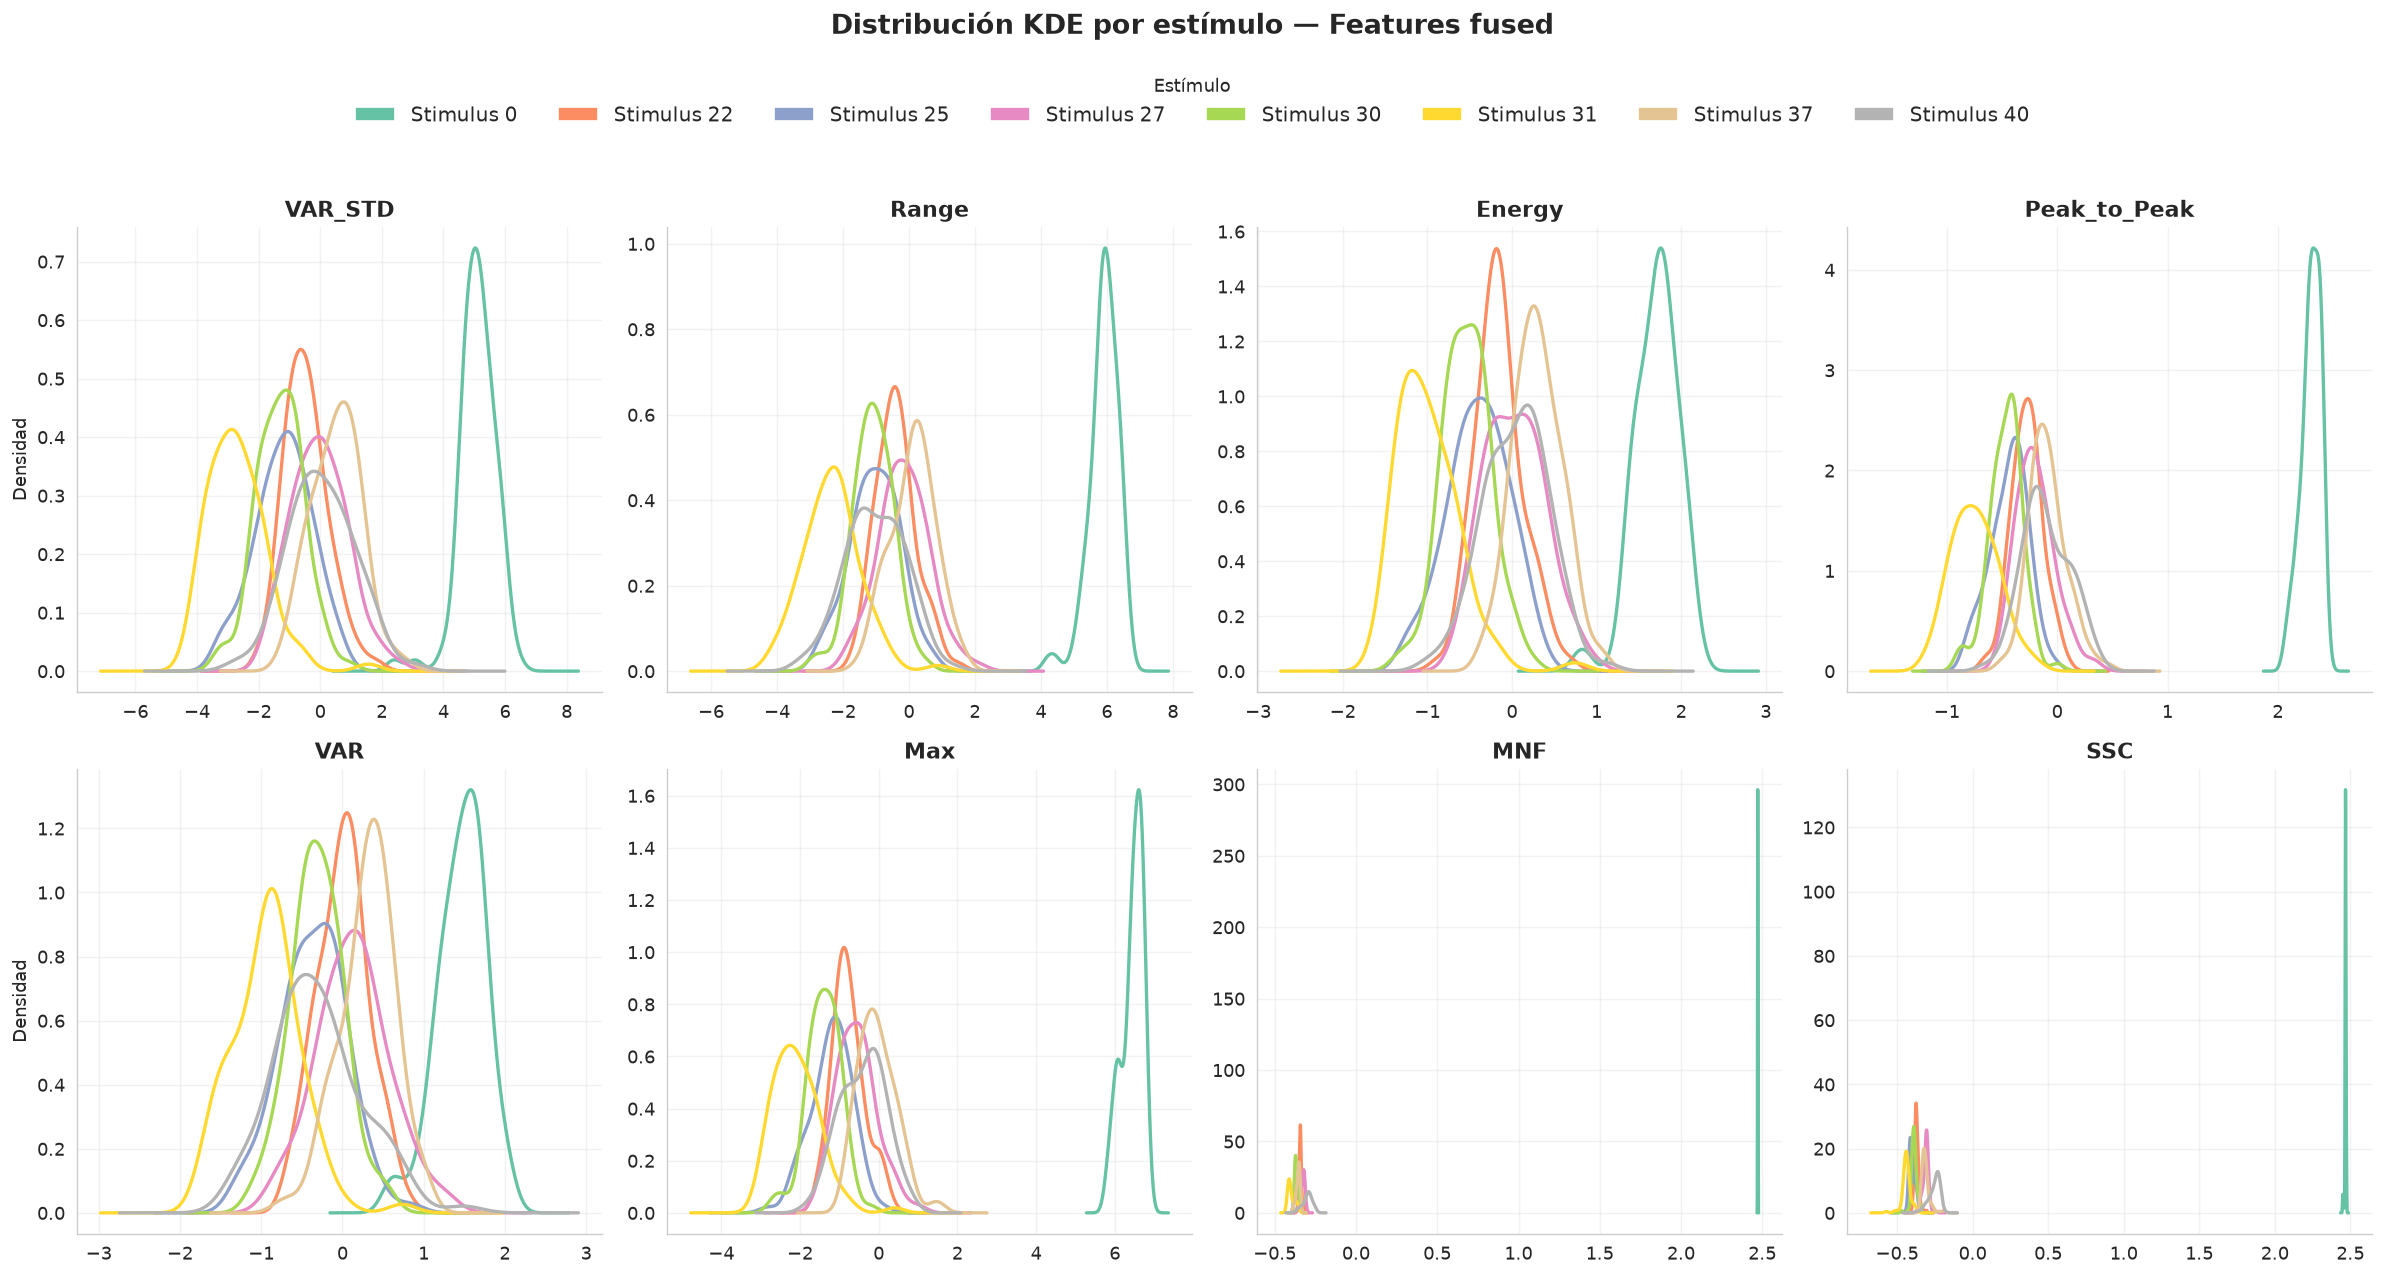

In [87]:
plot_kde_grid(df_fused, FEATURES)

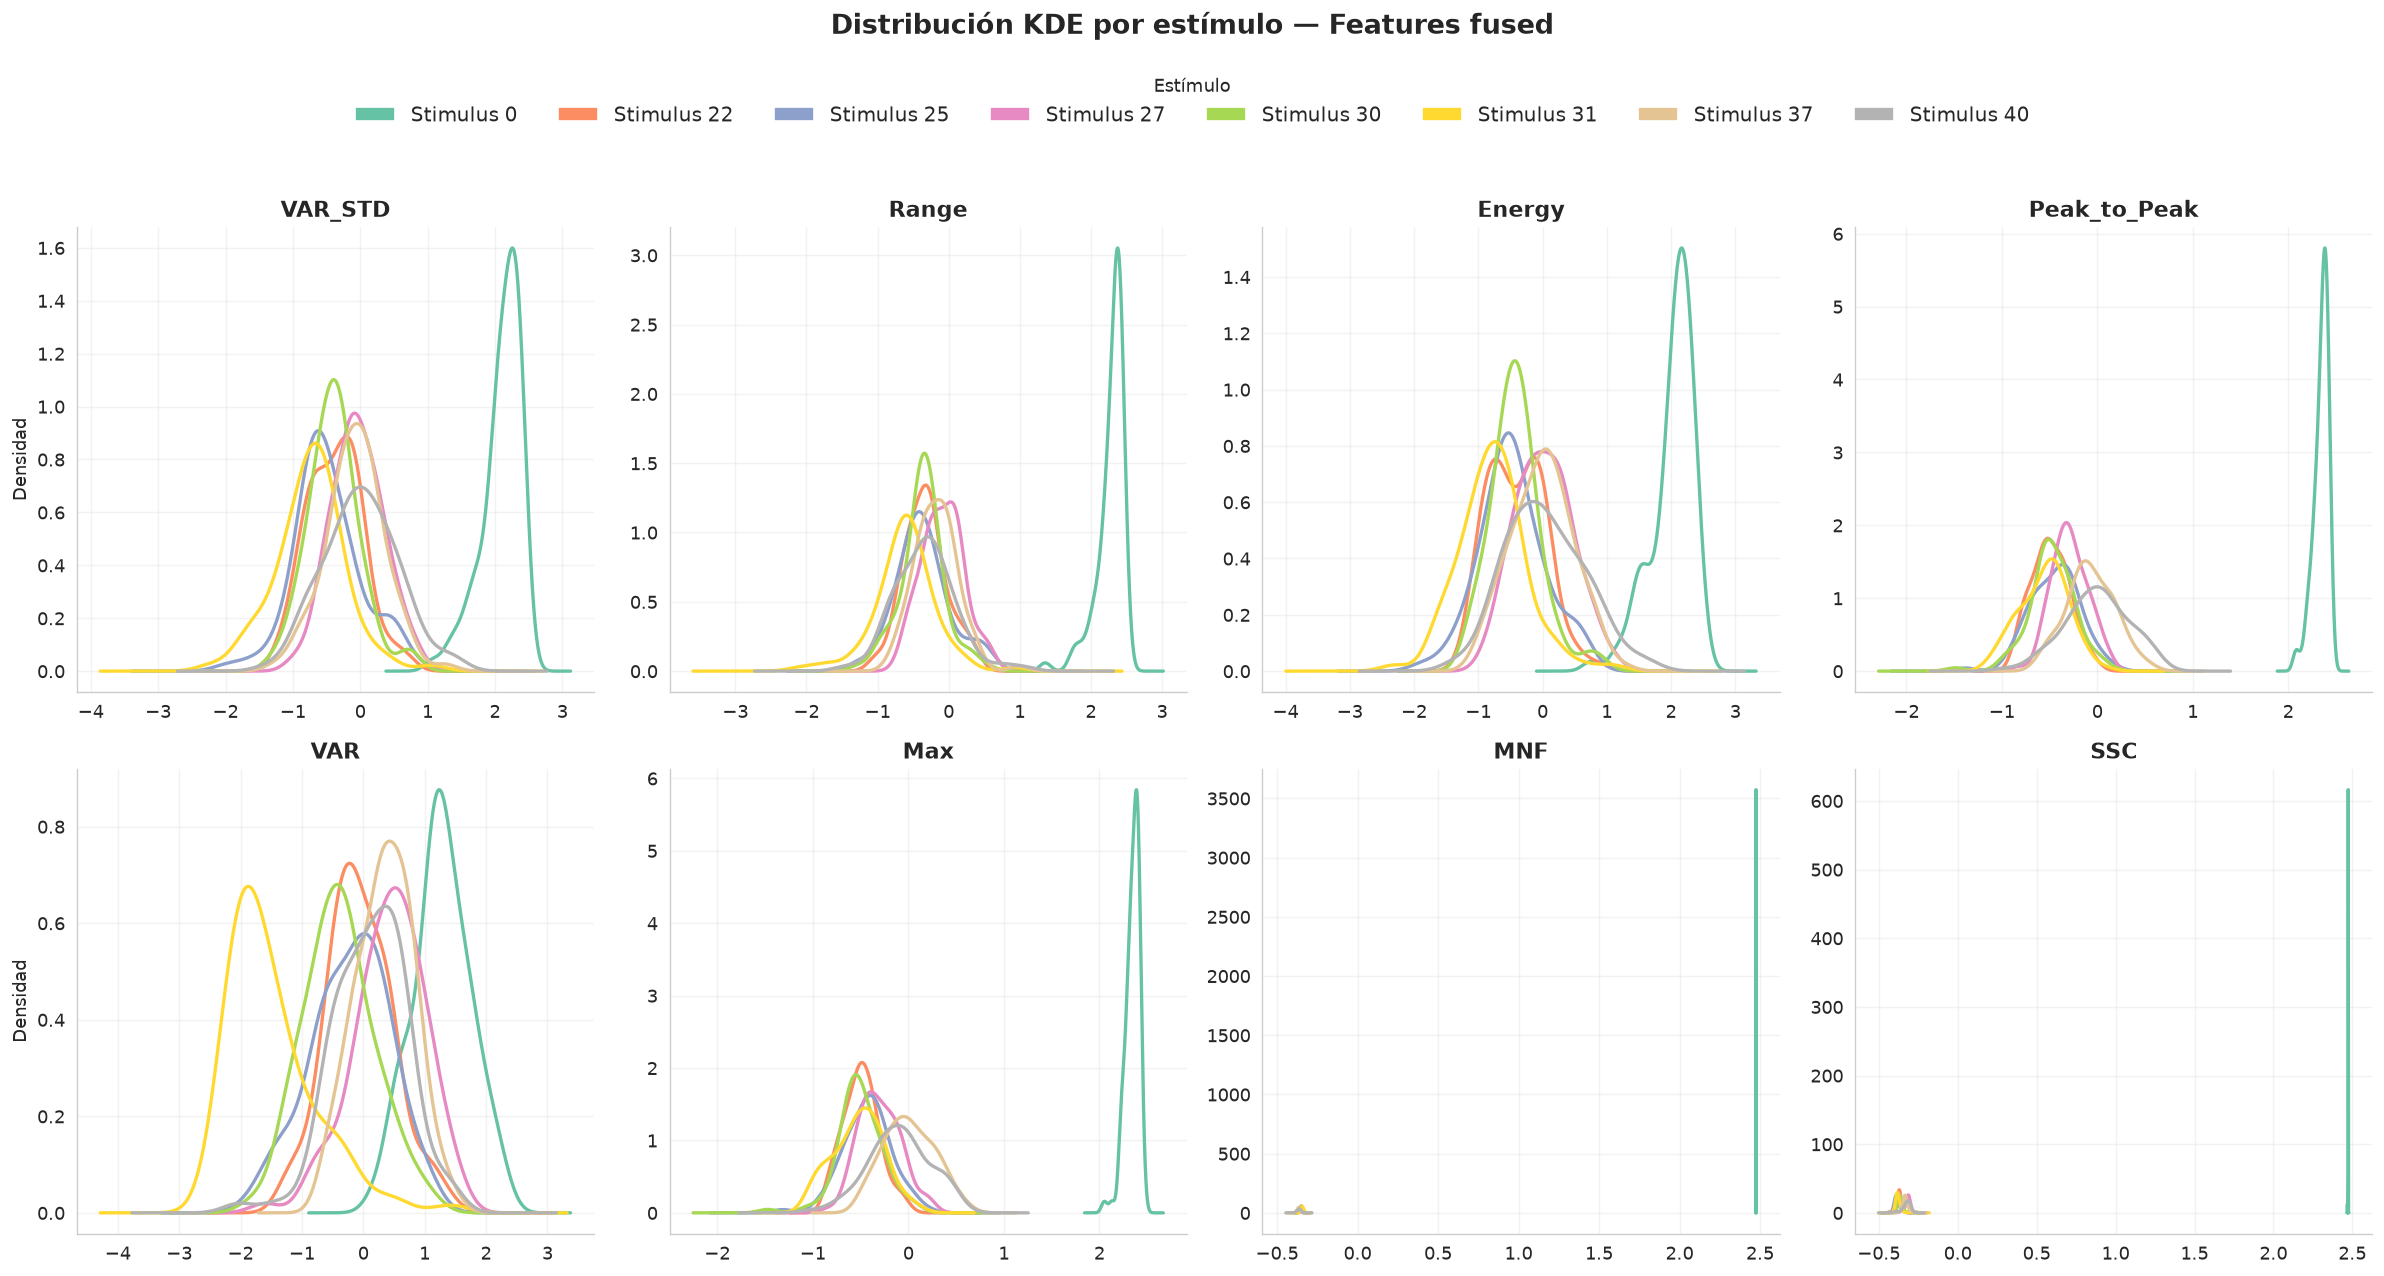

In [88]:
plot_kde_grid(df_best_channels, FEATURES)

In [91]:
import matplotlib.lines as mlines

def plot_kde_all_channels(df, features, hue_col='stimulus', title='Distribución KDE por estímulo — Features fused'):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    
    # 1. Fix the palette and the order of stimuli
    stimuli_order = sorted(df[hue_col].unique())
    palette = sns.color_palette('Set2', n_colors=len(stimuli_order))
    stim_palette = dict(zip(stimuli_order, palette))

    for i, feat in enumerate(features):
        ax = axes[i]
        channel_cols = [col for col in df.columns if feat in col and 'Channel' in col]
        
        df_melted = df[[hue_col] + channel_cols].melt(
            id_vars=[hue_col], 
            value_vars=channel_cols, 
            value_name='value'
        )
        
        sns.kdeplot(
            data=df_melted,
            x='value',
            hue=hue_col,
            hue_order=stimuli_order, # Force order
            palette=stim_palette,    # Force colors
            ax=ax,
            fill=False,
            linewidth=2,
            legend=False # We will build a custom global legend
        )
        
        ax.set_title(feat, fontweight='bold', fontsize=14)
        ax.set_xlabel('Value' if i >= 4 else '')
        ax.set_ylabel('Density' if i % 4 == 0 else '')
        ax.grid(True, alpha=0.2)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)

    # 2. CREATE CUSTOM LEGEND (Exactly like the image)
    # Create "proxy artists" (lines) for the legend
    legend_handles = [mlines.Line2D([], [], color=color, linewidth=2, label=stim) 
                     for stim, color in stim_palette.items()]

    fig.legend(
        handles=legend_handles, 
        title=hue_col.capitalize(), 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.96), 
        ncol=len(stimuli_order), 
        frameon=False,
        fontsize=12,
        title_fontsize=13
    )

    plt.suptitle(title, fontweight='bold', fontsize=18, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

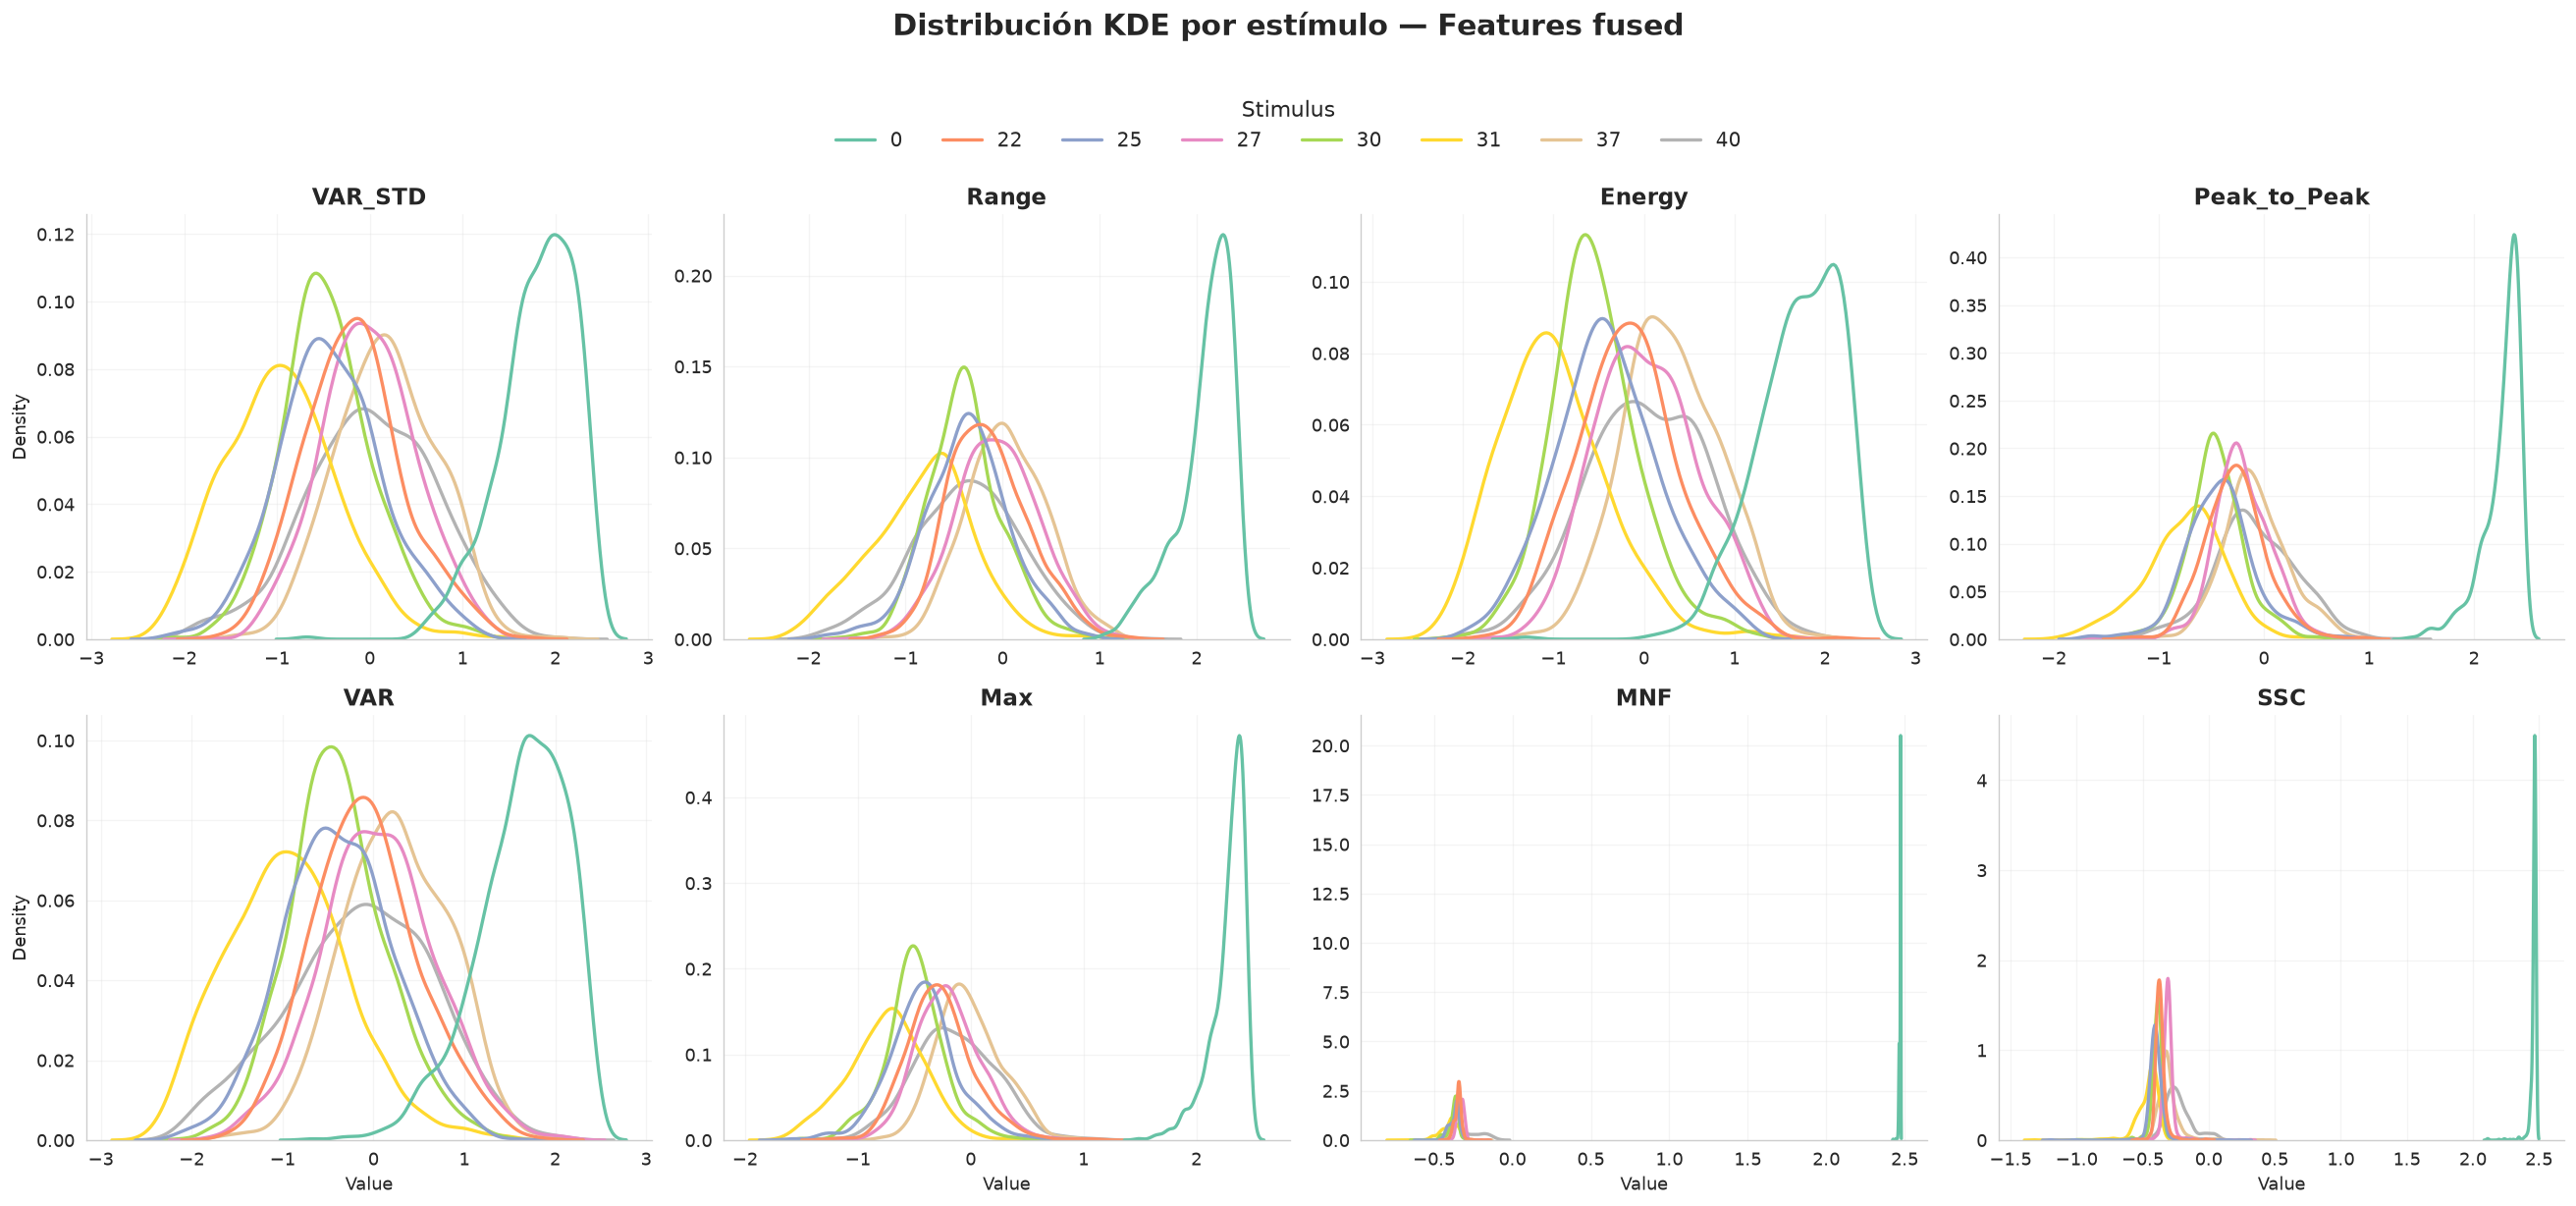

In [92]:
plot_kde_all_channels(df_norm, FEATURES)